# Exercises for Section 3.4 Analytical approximations

This notebook contains the solutions to the exercises
from [Section 3.4 Analytical approximations]()
in the **No Bullshit Guide to Statistics**.

### Notebook setup

In [1]:
# Ensure required Python modules are installed
%pip install --quiet numpy scipy seaborn pandas ministats

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Figures setup
plt.clf()  # needed otherwise `sns.set_theme` doesn't work
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={"figure.figsize": (6, 1.6)},
)
%config InlineBackend.figure_format = "retina"

<Figure size 640x480 with 0 Axes>

In [4]:
# Simplified int and float __repr__
np.set_printoptions(legacy='1.25')

In [5]:
# Download datasets/ directory if necessary
from ministats import ensure_datasets
ensure_datasets()

datasets/ directory already exists.


$\def\stderr#1{\mathbf{se}_{#1}}$
$\def\stderrhat#1{\hat{\mathbf{se}}_{#1}}$
$\newcommand{\Mean}{\textbf{Mean}}$
$\newcommand{\Var}{\textbf{Var}}$
$\newcommand{\Std}{\textbf{Std}}$
$\newcommand{\Freq}{\textbf{Freq}}$
$\newcommand{\RelFreq}{\textbf{RelFreq}}$
$\newcommand{\DMeans}{\textbf{DMeans}}$
$\newcommand{\Prop}{\textbf{Prop}}$
$\newcommand{\DProps}{\textbf{DProps}}$
$$
\newcommand{\CI}[1]{\textbf{CI}_{#1}}
\newcommand{\CIL}[1]{\textbf{L}_{#1}}
\newcommand{\CIU}[1]{\textbf{U}_{#1}}
\newcommand{\ci}[1]{\textbf{ci}_{#1}}
\newcommand{\cil}[1]{\textbf{l}_{#1}}
\newcommand{\ciu}[1]{\textbf{u}_{#1}}
$$
(this cell contains the macro definitions like $\stderr{\overline{\mathbf{x}}}$, $\stderrhat{}$, $\Mean$, ...)

## Exercises

### E3.30

z-test

Compute the $p$-value for hypothesis test of the mean in Batch 05 of the kombucha dataset.

In [6]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample05 = kombucha[kombucha["batch"]==5]["volume"]
len(ksample05)

40

In [7]:
ksample05.head()

107     998.35
108     998.92
109    1005.38
110    1007.20
111    1010.62
Name: volume, dtype: float64

**a)** 
The two competing hypotheses are:
$$ 
  H_0: \mu = \mu_{K_0}
  \qquad\text{and}\qquad
  H_A: \mu \neq \mu_{K_0},
$$
where $\mu_{K_0}=1000$ is the expected mean when the production line is working as expected.
We assume the population standard deviation is $\sigma_{K_0}=10$.

In [9]:
# b) Compute the observed mean
obsmean05 = np.mean(ksample05)
obsmean05

1002.53475

In [11]:
# Population properties under H0
muK0 = 1000
sigmaK0 = 10

# Compute the standard error of the mean
se05 = sigmaK0 / np.sqrt(40)

# c) Sampling distribution of the mean under H0
from scipy.stats import norm
rvKbar0 = norm(muK0, se05)

In [13]:
# d) Compute the p-value of `obsmean05` under H0
obsdev05 = abs(obsmean05 - muK0)
pvalue05 = rvKbar0.cdf(muK0-obsdev05) + (1-rvKbar0.cdf(muK0+obsdev05))
pvalue05

0.10890890053391405

The $p$-value is greater than $\alpha = 0.05$ so we have failed to reject $H_0$.
Batch 05 is OK.

Let's plot the sampling distribution of the mean $\overline{\mathbf{K}}_0$ under $H_0$
and the observed sample mean $\overline{\mathbf{k}}_{05}$.

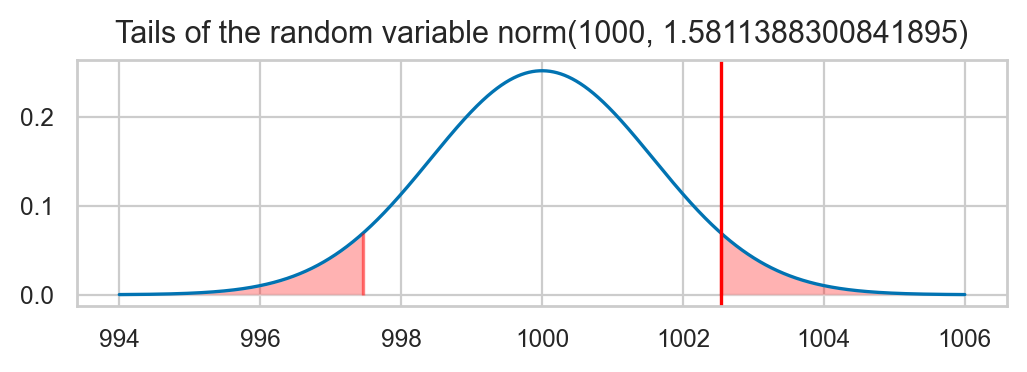

In [14]:
from ministats import calc_prob_and_plot_tails
calc_prob_and_plot_tails(rvKbar0, muK0-obsdev05, muK0+obsdev05, xlims=[994,1006])
plt.axvline(obsmean05, color="red");

The function `ztest` from the `ministats` library
performs all the steps of the $z$-test for the mean.
We can use this function to check we got the above calculations right.

In [15]:
# Check answer using `ministats` helper function
from ministats import ztest
ztest(ksample05, mu0=1000, sigma0=10)

0.10890890053391405

### E3.31

z-test
Compute the $p$-value for hypothesis test of the mean in Batch 06 of the kombucha dataset.

In [16]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample06 = kombucha[kombucha["batch"]==6]["volume"]
len(ksample06)

40

In [17]:
ksample06.head()

147     991.88
148    1002.29
149     997.18
150     986.01
151     970.13
Name: volume, dtype: float64

In [19]:
# Compute the observed mean
obsmean06 = np.mean(ksample06)
obsmean06

995.9955

In [21]:
# a) Calculate z-statistic then use standard normal as the reference distribution
# Population properties under H0
muK0 = 1000
sigmaK0 = 10

# Compute the standard error of the mean
se06 = sigmaK0 / np.sqrt(40)

# Calculate the z-statistic
z06 = (obsmean06 - muK0) / se06
print("z06 =", z06)

# Build a computer model for the standard normal
from scipy.stats import norm
rvZ0 = norm(0, 1)

# Compute the p-value of `z06` under `rvZ0`
pvalue06 = rvZ0.cdf(-abs(z06)) + (1-rvZ0.cdf(abs(z06)))
pvalue06

z06 = -2.53266817802886


0.011319805342656829

In [23]:
# b) Directly calculation of p-value of `obsmean06` under `rvKbar0`
# Population properties under H0
muK0 = 1000
sigmaK0 = 10

# Compute the standard error of the mean
se06 = sigmaK0 / np.sqrt(40)

# Obtain the sampling distribution of the mean under H0
from scipy.stats import norm
rvKbar0 = norm(muK0, se06)

# Compute the p-value of `obsmean06` under H0
obsdev06 = abs(obsmean06 - muK0)
pvalue06 = rvKbar0.cdf(muK0-obsdev06) + (1-rvKbar0.cdf(muK0+obsdev06))
pvalue06

0.011319805342656829

The $p$-value is less than $\alpha = 0.05$ so we reject $H_0$.
Batch 06 is irregular.

Let's plot the sampling distribution $\overline{\mathbf{K}}_0$
under $H_0$ and the observed sample mean $\overline{\mathbf{k}}_{06}$.

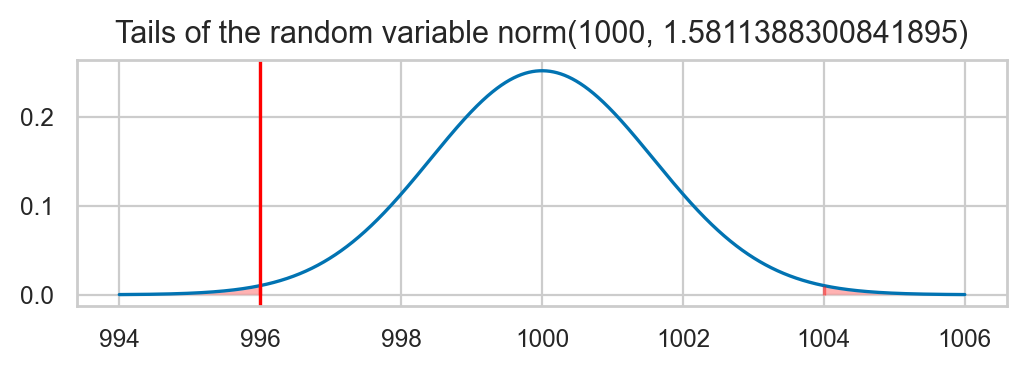

In [24]:
from ministats import calc_prob_and_plot_tails
calc_prob_and_plot_tails(rvKbar0, muK0-obsdev06, muK0+obsdev06, xlims=[994,1006])
plt.axvline(obsmean06, color="red");

The function `ztest` from the `ministats` library
performs all the steps of the $z$-test for the mean.
We can use this function to check we got the above calculations right.

In [25]:
# Check answer using `ministats` helper function
from ministats import ztest
ztest(ksample06, mu0=1000, sigma0=10)

0.011319805342656829

### E3.32

t-test Batch 05 of the kombucha dataset.

In [26]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample05 = kombucha[kombucha["batch"]==5]["volume"]
len(ksample05)

40

**a)** 
The two competing hypotheses are:
$$ 
  H_0: \mu = \mu_{K_0}
  \qquad\text{and}\qquad
  H_A: \mu \neq \mu_{K_0},
$$
where $\mu_{K_0}=1000$ is the expected mean when the production line is working as expected.
We assume the population standard deviation $\sigma_{K_0}$ is unknown.

In [28]:
# Compute the observed sample mean
obsmean05 = np.mean(ksample05)
obsmean05

1002.53475

In [30]:
# Compute the sample standard deviation
s05 = ksample05.std()
s05

6.553408972944293

In [32]:
# Compute the estimated standard error of the mean
sehat05 = s05 / np.sqrt(40)
sehat05

1.036184939654437

In [33]:
# Population mean under H0
muK0 = 1000

# d) Compute the value of the t-statistic
t05 = (obsmean05 - muK0) / sehat05
t05

2.4462331993025868

In [34]:
# c) Compute the p-value of `t05` under the standard t-distribution
from scipy.stats import t as tdist
rvT0 = tdist(df=39)

pvalue05 = rvT0.cdf(-abs(t05)) + (1-rvT0.cdf(abs(t05)))
pvalue05

0.019048565151749557

In [35]:
# f) Compute the p-value of `obsmean05` under H0
from scipy.stats import t as tdist
rvTKbar0 = tdist(df=39, loc=muK0, scale=sehat05)
obsdev05 = abs(obsmean05 - muK0)
pvalue05 = rvTKbar0.cdf(muK0-obsdev05) + (1-rvTKbar0.cdf(muK0+obsdev05))
pvalue05

0.019048565151749557

The $p$-value is less than $\alpha = 0.05$ so we reject $H_0$.
Batch 05 seems to be irregular.

Let's plot the sampling distribution $T_{\overline{\mathbf{K}}_0}$
under $H_0$ and the observed sample mean $\overline{\mathbf{k}}_{05}$.

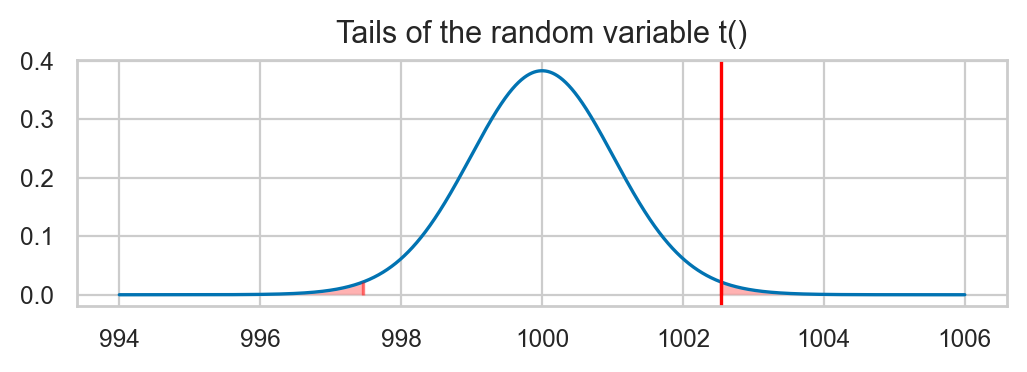

In [38]:
from ministats import calc_prob_and_plot_tails
calc_prob_and_plot_tails(rvTKbar0, muK0-obsdev05, muK0+obsdev05, xlims=[994,1006])
plt.axvline(obsmean05, color="red");

The function `ttest_mean` from the `ministats` library
performs all the steps of the $t$-test for the mean.
We can use this function to check we got the above calculations right.

In [39]:
# Check answer using `ministats` helper function
from ministats import ttest_mean
ttest_mean(ksample05, mu0=1000)

0.019048565151749557

### E3.33

T-test $p$-value for hypothesis test of the mean in Batch 06 of the kombucha dataset.

In [40]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample06 = kombucha[kombucha["batch"]==6]["volume"]
len(ksample06)

40

In [42]:
# Compute the observed mean
obsmean06 = np.mean(ksample06)
obsmean06

995.9955

In [44]:
# Compute the estimated standard error of the mean
s06 = ksample06.std()
sehat06 = s06 / np.sqrt(40)

# Compute the value of the t-statistic
t06 = (obsmean06 - 1000) / sehat06

# Compute the p-value of `t05` under the standard t-distribution
from scipy.stats import t as tdist
rvT0 = tdist(df=39)
pvalue06 = rvT0.cdf(-abs(t06)) + (1-rvT0.cdf(abs(t06)))
pvalue06

0.023584164666307347

The $p$-value is less than $\alpha = 0.05$ so we reject $H_0$.
Batch 06 is irregular.

Let's plot the approximation to $T_{\overline{\mathbf{K}}_0}$
to the sampling distribution of the mean under $H_0$
and the observed sample mean $\overline{\mathbf{k}}_{06}$.

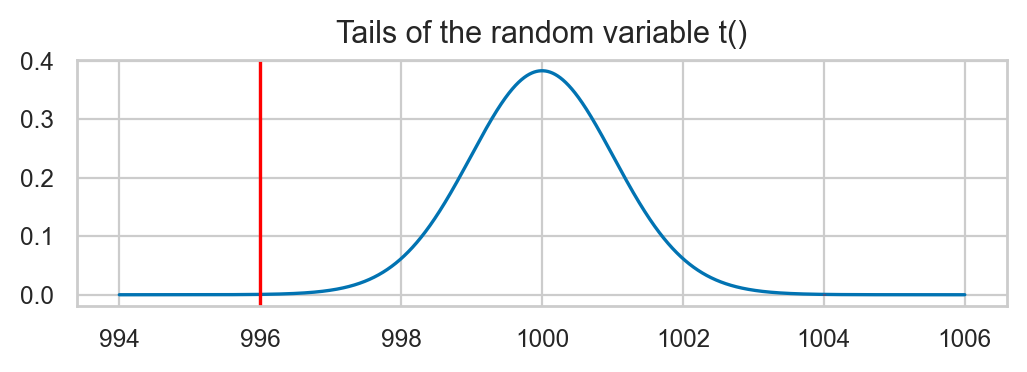

In [45]:
from ministats import calc_prob_and_plot_tails
calc_prob_and_plot_tails(rvTKbar0, muK0-obsdev06, muK0+obsdev06, xlims=[994,1006])
plt.axvline(obsmean06, color="red");

The function `ttest_mean` from the `ministats` library
performs all the steps of the $t$-test for the mean.
We can use this function to check we got the above calculations right.

In [46]:
# Check answer using `ministats` helper function
from ministats import ttest_mean
ttest_mean(ksample06, mu0=1000)

0.023584164666307347

In [47]:
# Point estimate for the effect size
obsmean06 - 1000

-4.004500000000007

In [49]:
# Construct a 90% confidence interval for the effect size
from ministats import ci_mean
cimu06 = ci_mean(ksample06, alpha=0.1, method="a")
ciDelta06 = [cimu06[0]-1000, cimu06[1]-1000]
ciDelta06

[-6.868076308379614, -1.1409236916204009]

### E3.34

Run the test for the variance on Batch 01.

compute q then use standard reference dist

In [50]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample01 = kombucha[kombucha["batch"]==1]["volume"]
len(ksample01)

40

In [51]:
ksample01.head()

0    1016.24
1     993.88
2     994.72
3     989.27
4    1008.65
Name: volume, dtype: float64

In [53]:
# Compute the observed variance
obsvar01 = ksample01.var()
obsvar01

95.43654198717958

In [55]:
# Population standard deviation under H0
sigmaK0 = 10

# Calculate the q-statistic
scale = sigmaK0**2 / 39
q01 = obsvar01 /  scale
q01

37.22025137500003

In [56]:
# Compute the p-value of `q01` under the standard chi-square dist.
from scipy.stats import chi2
rvX2 = chi2(39)
pvalue01 = 1 - rvX2.cdf(q01)
pvalue01

0.5512424304744498

The $p$-value is greater than $\alpha=0.05$
so we fail to reject $H_0$.

Let's plot the reference distribution $\chi^2(39)$
and the observed value of the $q$-statistic.

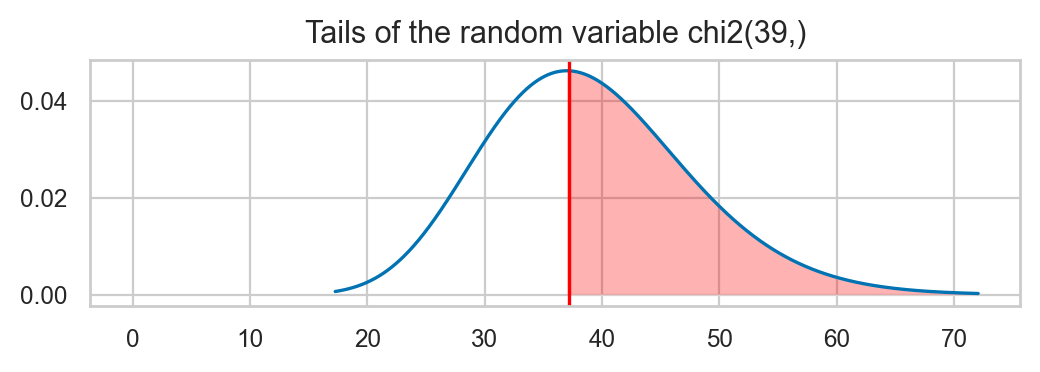

In [57]:
from ministats import calc_prob_and_plot_tails
calc_prob_and_plot_tails(rvX2, 0, q01)
plt.axvline(q01 , color="red");

The function `chi2test_var` from the `ministats` library
performs all the steps of the $\chi^2$-test for the variance.
We can use this function to check we got the above calculations right.

In [58]:
# Check answer using `ministats` helper function
from ministats import chi2test_var
chi2test_var(ksample01, sigma0=10)

0.5512424304744498

### E3.35

Run the test for the variance on Batch 01.

In [59]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample01 = kombucha[kombucha["batch"]==1]["volume"]
len(ksample01)

40

In [60]:
ksample01.head()

0    1016.24
1     993.88
2     994.72
3     989.27
4    1008.65
Name: volume, dtype: float64

In [62]:
# Compute the observed variance
obsvar01 = ksample01.var()
obsvar01

95.43654198717958

In [64]:
# Population standard deviation under H0
sigmaK0 = 10

# Obtain the sampling distribution of the variance under H0
from scipy.stats import chi2
scale = sigmaK0**2 / 39
rvS2K0 = chi2(df=39, scale=scale)

# Compute the p-value of `obsvar01` under H0
pvalue01 = 1 - rvS2K0.cdf(obsvar01)
pvalue01

0.5512424304744498

The $p$-value is greater than $\alpha=0.05$
so we fail to reject $H_0$.

Let's plot the sampling distribution $S_{\mathbf{K}_0}^2$
under $H_0$ and the observed sample variance $s_{\mathbf{k}_{01}}^2$.

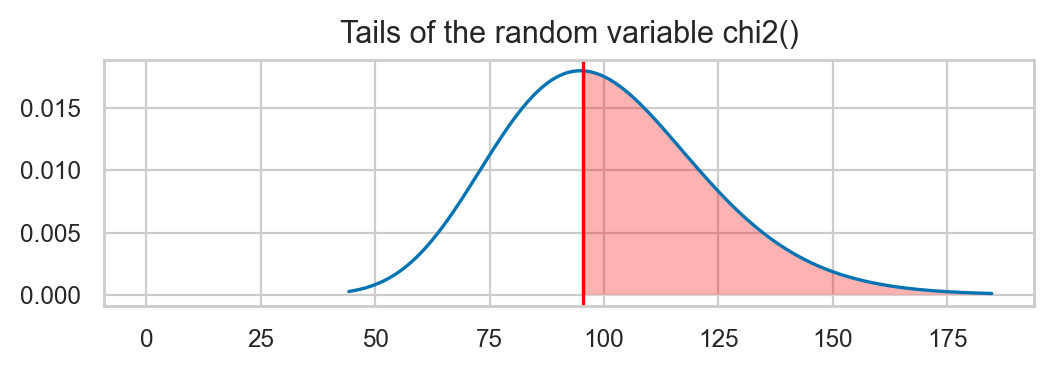

In [65]:
from ministats import calc_prob_and_plot_tails
calc_prob_and_plot_tails(rvS2K0, 0, obsvar01)
plt.axvline(obsvar01 , color="red");

The function `chi2test_var` from the `ministats` library
performs all the steps of the $\chi^2$-test for the variance.
We can use this function to check we got the above calculations right.

In [66]:
# Check answer using `ministats` helper function
from ministats import chi2test_var
chi2test_var(ksample01, sigma0=10)

0.5512424304744498

### E3.36

t-test drug discovery


In [67]:
# The observed data sample
isample = [101.9, 100.4,  99.9, 100.4, 101.1,
           100.8, 100.8, 101.2,  99.8, 102.5]

In [69]:
# Compute the observed mean
obsimean = np.mean(isample)
obsimean

100.88

In [71]:
# Compute the sample standard deviation
obsistd = np.std(isample, ddof=1)
obsistd

0.8443274772793364

In [73]:
# Population mean under H0
muI0 = 100

# Compute the estimated standard error of the mean
sehat =  obsistd / np.sqrt(10)

# Obtain the sampling distribution of the mean under H0
from scipy.stats import t as tdist
rvTIbar0 = tdist(df=9, loc=muI0, scale=sehat)

# Compute the two-sided p-value of `obsimean` under H0
obsidev = abs(obsimean - muI0)
pvalue = rvTIbar0.cdf(muI0-obsidev) + (1-rvTIbar0.cdf(muI0+obsidev))
pvalue

0.009290726616486602

In [74]:
# Check answer using `ministats` helper function
from ministats import ttest_mean
ttest_mean(isample, mu0=100)

0.009290726616486602

### E3.37


t-test deflections

In [75]:
# Observed deflection measurements
dsample = [0.63, 1.12, 1.61, 2.10, 2.59]

In [77]:
# Compute the observed mean
obsdmean = np.mean(dsample)
obsdmean

1.61

In [79]:
# Compute the sample standard deviation
obsdstd = np.std(dsample, ddof=1)
obsdstd

0.7747580267412529

In [81]:
# Population mean under H0
muD0 = 0.87

# Compute the estimated standard error of the mean
sehat = obsdstd / np.sqrt(5)
print("sehat =", sehat)

# Obtain the sampling distribution of the mean under H0
from scipy.stats import t as tdist
rvTDbar0 = tdist(df=4, loc=muD0, scale=sehat)

# Compute the one-sided p-value of `obsdmean` under H0
pvalue = 1 - rvTDbar0.cdf(obsdmean)
pvalue

sehat = 0.3464823227814083


0.04978101360614473

### E3.38

See PDF

